In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
#install the package that runs a hampel filter--this is what cleans the spikes out of the data caused by removing the hobo sensors from the wells

In [3]:
pip install hampel

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [5]:
import os #allows python to communicate directly with the computer's operating system

In [6]:
#reading the continuous data
P4hobodf = pd.read_csv("P4_current.csv") 
P4hobodf["Date-Time"] = pd.to_datetime(P4hobodf["Date-Time"])
P4date = P4hobodf["Date-Time"] 
P4sliceddate = P4date[1:] 

In [20]:
#filtering the continuous data for the outlier spikes where the hobo probe was removed from the piezometer
P4filteredtemp = hampel(P4hobodf["Temperature"], window_size=6, n_sigma=1.5)
P4filteredtempseries = pd.Series(P4filteredtemp.filtered_data, index = P4hobodf.index) 
P4filteredtemp = P4filteredtempseries[1:]

In [21]:
#reading the manual data
P4mandf = pd.read_csv("P4ManualData.csv", index_col=False)
P4mandf.loc[:,"Temp bottom before"] 
P4mandf["Date"] = pd.to_datetime(P4mandf["Date"]) 

In [22]:
#reading in the NOAA air temp data
weatherdf = pd.read_csv("NOAAHastingsDam2Since2024.csv") #"NOAAHastingsDam2.csv" is a placeholder for the csv with your weather data
#weatherdf = weatherdf.drop(np.arange(0, 335))
weatherdf["Date"] = pd.to_datetime(weatherdf["Date"])
weatherdf

,Date,Precipitation (inches),Snowfall (inches),Snow depth (inches),Maximum Fahrenheit Teperature,Minimum Fahrenheit Teperature,Mean Fahrenheit Teperature,Mean Celcius Teperature,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,count,717,706,693,627,616,597
0,2024-07-01,0,0,0,73.0,55.0,64.0,17.777778,HASTINGS DAM 2,NaN,NaN,NaN,total,60.71,51.5,441.0,0.0,0.0,0.0
1,2024-07-02,0.29,0,0,74.0,61.0,67.5,19.722222,COOP - 213567,NaN,NaN,NaN,average,0.08,0.1,1.0,59.0,40.0,49.8
2,2024-07-03,0,0,0,71.0,62.0,66.5,19.166667,NaN,NaN,NaN,NaN,min,0.00,0.0,0.0,-6.0,-19.0,-12.5
3,2024-07-04,0,0,0,85.0,64.0,74.5,23.611111,NaN,NaN,NaN,NaN,max,2.85,8.0,8.0,97.0,80.0,88.0
4,2024-07-05,0.59,0,0,69.0,63.0,66.0,18.888889,NaN,NaN,NaN,NaN,median,0.00,0.0,0.0,64.0,44.0,54.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
719,2026-06-20,0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
720,2026-06-21,0,NaN,NaN,77.0,56.0,66.5,19.166667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
721,2026-06-22,0,NaN,NaN,76.0,55.0,65.5,18.611111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
722,2026-06-23,0,NaN,NaN,78.0,57.0,67.5,19.722222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
#reading C4 continuous data
C4hobodf = pd.read_csv("P4_creek_current.csv") 
C4hobodf["Date-Time"] = pd.to_datetime(C4hobodf["Date-Time"]) 
C4date = C4hobodf["Date-Time"]
C4hobodfdate = C4date[1:]

In [24]:
#filtering the C4 data for the outlier spikes where the hobo probe was removed from the piezometer
C4filteredhobo = hampel(C4hobodf["Temperature"], window_size=6, n_sigma=1.5)
C4filteredhoboseries = pd.Series(C4filteredhobo.filtered_data, index = C4hobodf.index)
C4filteredhobo = C4filteredhoboseries[1:]

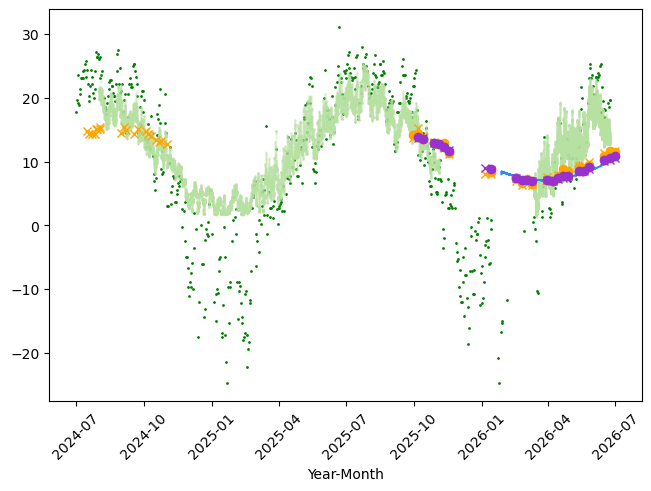

In [25]:
#creating the plot
P4mandf.columns = P4mandf.columns.str.strip()  #This line was generated by Google Gemini to remove the leading and trailing whitespaces in the mandf dataframe.  

fig, ax = plt.subplots(layout='constrained')
ax.plot(P4sliceddate, P4filteredtemp, color="dodgerblue", label = "P4 continuous temperature")
ax.plot(P4mandf.Date, P4mandf.loc[:,"Temp top before"], 'x', color = "orange", label = "manual temperature at top before pumping") #each variable in the manual field measurmemts data set is called by their column instead of naming each variable. The placeholders here are mandf.Date (which you should replace with the nameofdataframe.nameofcolumnfortime) and mandf.loc[:,"Temp top before"] (which you should replace with nameofdataframe.loc[:, "Name of column for parameter"]). 
ax.plot(P4mandf.Date, P4mandf.loc[:,"Temp bottom before"], 'x', color = "darkorchid", label = "manual temperature at bottom before pumping")
ax.plot(P4mandf.Date, P4mandf.loc[:,"Temp top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
ax.plot(P4mandf.Date, P4mandf.loc[:,"Temp bottom after"], 'o', color = "darkorchid", label = "manual temperature at bottom after pumping")
ax.scatter(weatherdf.Date, weatherdf.loc[:,"Mean  Celcius Teperature"], color = "green", s = 1, label = "air temperature") #the air temperature data
# plt.plot(C4hobodfdate, C4filteredhobo, color = "xkcd:light grey green", label = "C4 continuous temperature data")
ax.scatter(C4hobodfdate, C4filteredhobo, color = "xkcd:light grey green", alpha = 0.2, s = 0.2, label = "C2 continuous temperature data")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
# plt.ylabel("Temperature (°C)") #Temperature (°C) is a placeholder.
# plt.ylim((0, 20))

# fig.legend(loc='outside upper right')

plt.show()

In [ ]:
#P4 SPC

In [28]:
#dropping the 2024-07-16 thru 2024-11-01 data because it seems to have been measured incorrectly.
P4mandf = P4mandf.drop(np.arange(0, 20))
print(P4mandf.loc[:,"SPC top before"])

20    648.0
21    679.0
22    701.0
23    730.0
24    767.0
25    779.0
26    777.0
27    700.0
28    706.0
29    792.0
30    803.0
31    808.0
32    803.0
33    812.0
34    814.0
35    814.0
36    844.0
37    828.0
38    823.0
39    822.0
40    826.0
41    807.0
42    799.0
43    804.0
Name: SPC top before, dtype: float64


In [29]:
print(P4hobodf["Specific Conductivity"])

0          0.000000
1        684.298523
2        687.392212
3        688.137329
4        688.777161
            ...    
14108    697.086853
14109    697.078674
14110    697.050964
14111    697.085449
14112    697.045410
Name: Specific Conductivity, Length: 14113, dtype: float64


In [30]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
P4filteredSPC = hampel(P4hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)

print(P4filteredSPC.filtered_data)

0          0.000000
1        684.298523
2        687.392212
3        688.137329
4        688.777161
            ...    
14108    697.086853
14109    697.078674
14110    697.050964
14111    697.085449
14112    697.045410
Length: 14113, dtype: float32


In [31]:
P4filteredSPC = pd.Series(P4filteredSPC.filtered_data, index = P4hobodf.index)
P4filteredSPC = P4filteredSPC[1:]              #I used the google AI overview for this line of code :/

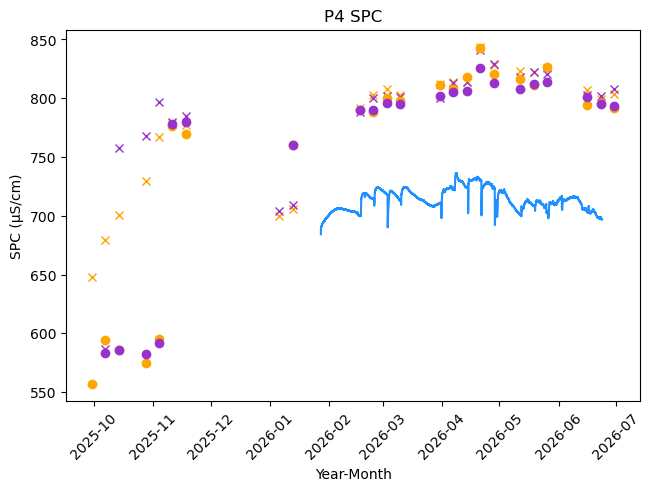

In [33]:

P4hobodate = P4hobodf["Date-Time"]
P4slicedhobodate = P4hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.plot(P4sliceddate, P4filteredSPC, color="dodgerblue", label = "HOBO continuous temperature")
ax.plot(P4mandf.Date, P4mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(P4mandf.Date, P4mandf.loc[:,"SPC bottom before"], 'x', color = "darkorchid", label = "manual SPC at bottom before pumping")
ax.plot(P4mandf.Date, P4mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(P4mandf.Date, P4mandf.loc[:,"SPC bottom after"], 'o', color = "darkorchid", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("P4 SPC")
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()